In [1]:
import os
import pandas as pd
import pickle
from IPython.display import Image

os.chdir(r'C:/Users/mikei/OneDrive/Desktop/Python/nba_breakout_analysis')

all_candidates = pd.read_csv('data/nba_breakout_candidates.csv')
with open('models/diff_model.pkl', 'rb') as f:
    diff_model = pickle.load(f)
with open('models/following_model.pkl', 'rb') as f:
    following_model = pickle.load(f)
with open('models/logit_model.pkl', 'rb') as f: 
    logit_model = pickle.load(f)        


# Is it just a Mirage: Can Breakout Players in the NBA Sustain their Surge in the Age of Tanking
**Author:** Mike Zhang
**Date:** 2026-03-31



## Introduction 

Since time immemorial, tanking has been an issue in the NBA. Over the past few years, with loads of generational talents like Victor Wembanyama and Cooper Flagg entering the league every year, the tanking measurements adopted by teams have become, well, more and more blatant, whether they are teams that were in the middle of a dog fight in the finals yet somehow predicted their best player was about to tear his achilles a few days later like the Pacers, accumulate assets for the future like the Nets, cross fingers for a miracle after trading away their franchise like the Mavs, or simply be the Sacramento Kings who started Kilian Hayes for the last game.

It's bad for the game, I get it. But at the same time, it allows teams to experiment with their lineups and develop players who otherwise might not get enough playing time to show what they can actually do on the court. Take the now all-star Deni Avdija as an example. After spending four underwhelming years in D.C., he was traded to the Blazers for cheap, and during his first season with the Blazers, he still merely looked like a high-caliber role player at best, averaging a serviceable 14/6/3 with mediocre efficiency, just slightly better than what he did with the Wizards. However, he suddenly emerged as a breakout candidate since the All-Star break, stuffing the statsheet with a stunning 23/9/5 line with an impressive 50%/40%/78% split. Avdija finished the 24-25 season strong, but rumors of him starting the 25-26 season off the bench were still circulating in the off-season, showing just how fans and analysts are treating stats from the so-called Mickey-mouse March with caution nowadays.

This raises a natural question: are post-All-Star breakouts on tanking teams real, or just noise?

## Data
All data for this project are obtained from the official `nba_api` endpoints. Breakout seasons span from 2014-15 to 2024-25, with following-season stats drawn through 2025-26. The 2019-20 season is excluded due to being disrupted by COVID-19. In order to capture the "big leap in a tanking team after the All-Star break" as accurately as possible, multiple inclusion criteria are implemented. 

To qualify, a player must: 
1. be no older than 28 (`AGE_post <= 28`)
2. be on a tanking team, defined as having a bottom-12 win rate (`W_PCT`) by the All-Star break 
3. be at least a rotation-level player before All-Star breaks, defined as averaging at least 10 minutes of playing time and playing at least 15 games (`MIN_pre >= 10 & GP_pre >= 15`) 
4. have demonstrated a breakout after All-Star breaks by either having a major PIE change of at least 0.02 (`PIE_change >= 0.02`) or a 30% jump in playing time per game (`MIN_post >= 1.3 * MIN_pre`)
5. not be an established star, defined as having a prior season PIE no greater than 0.11 (`PIE_prior <= 0.11`)
6. played at least 30 games the following season to ensure a sufficient sample for measuring following seasons' performance (`GP_following >= 30`)

 Ultimately, the inclusion criteria yield 120 players for my analysis.

 It's worth noticing that many of these criteria are rather arbitrary and based on my personal basketball knowledge as well as judgement. Although position isn't a significant variable in any of the regression models later on, it is also interesting to note that there are fewer centers (`n = 11`) than guards (`n = 72`) and fowards (`n = 37`) who qualify for our analysis. In addition, as shown in the boxplot below, centers generally show a tighter distribution of the changes in their pre- and post-All-Star break PIEs, compared with guards and fowards, suggesting that big men's development is slower and steadier, which alignes with common basketball knowledge.  

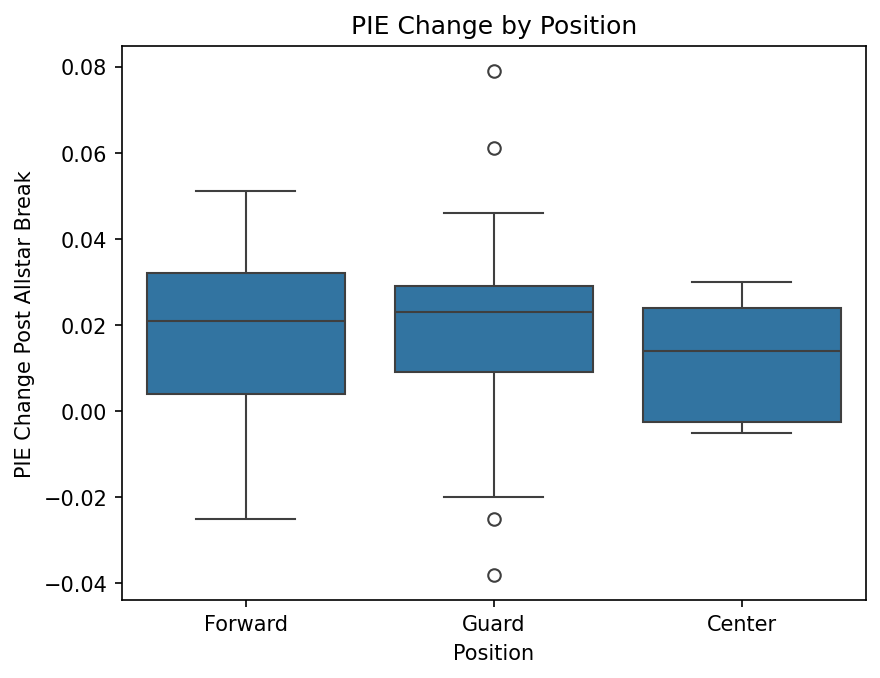

In [3]:
Image('plots/position_boxplot.png')

## Methods